In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score

import scipy.cluster.hierarchy as sch

In [2]:
df = pd.read_csv("train.csv")
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  object 
 3   Delivery_person_Ratings      45593 non-null  object 
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  45593 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            45593 non-null  object 
 12  Road_traffic_density         45593 non-null  object 
 13  Vehicle_conditio

,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition
count,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000
mean,17.017729,70.231332,17.465186,70.845702,1.023359
std,8.185109,22.883647,7.335122,21.118812,0.839065
min,-30.905562,-88.366217,0.010000,0.010000,0.000000
25%,12.933284,73.170000,12.988453,73.280000,0.000000
50%,18.546947,75.898497,18.633934,76.002574,1.000000
75%,22.728163,78.044095,22.785049,78.107044,2.000000
max,30.914057,88.433452,31.054057,88.563452,3.000000


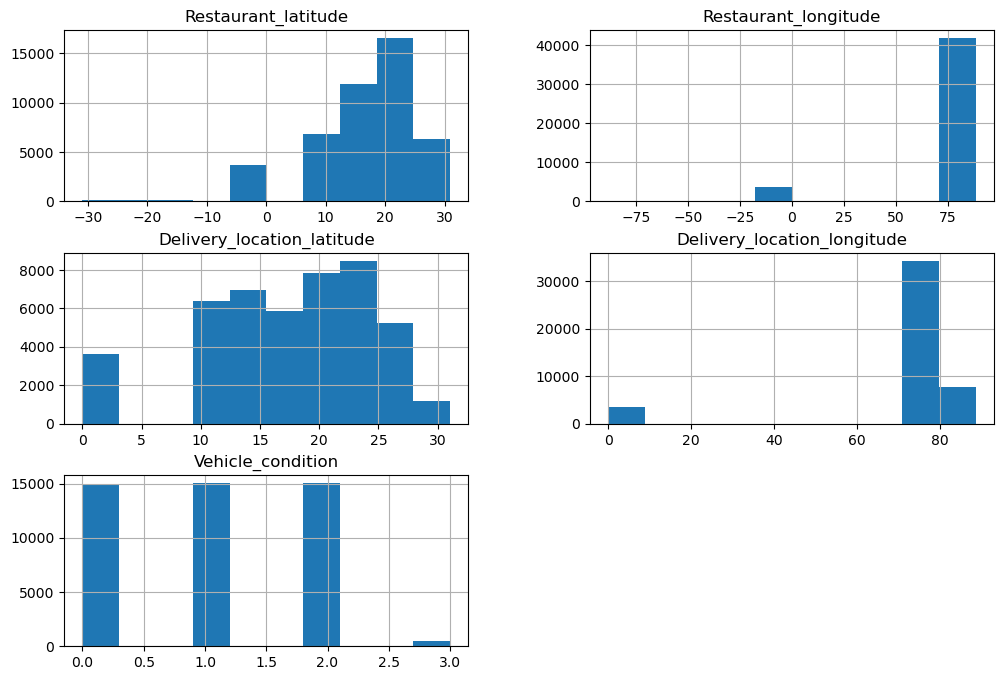

In [4]:
df.select_dtypes(include=np.number).hist(figsize=(12,8))
plt.show()

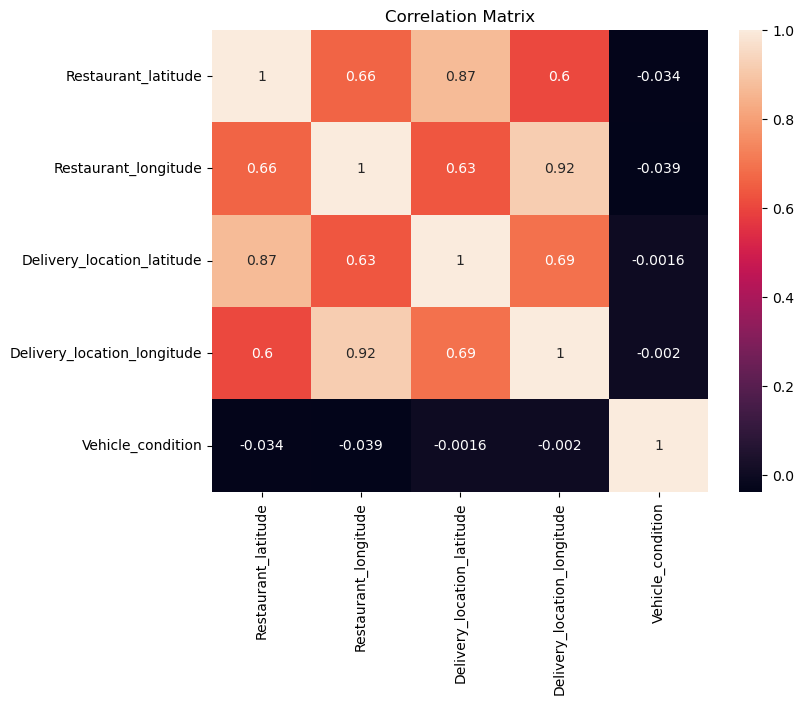

In [5]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

In [6]:
df = df.drop(columns=['ID', 'Order_ID'], errors='ignore')
df = df.fillna(df.median(numeric_only=True))

In [7]:
np.random.seed(42)

df['Age'] = np.random.randint(18, 60, len(df))
df['TotalOrders'] = np.random.randint(1, 50, len(df))
df['AvgSpend'] = np.random.randint(100, 1000, len(df))
df['AppUsageTime'] = np.random.randint(5, 120, len(df))

In [8]:
features = ['Age', 'TotalOrders', 'AvgSpend', 'AppUsageTime']
X = df[features]

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained Variance:", pca.explained_variance_ratio_)

Explained Variance: [0.25389834 0.25036757]


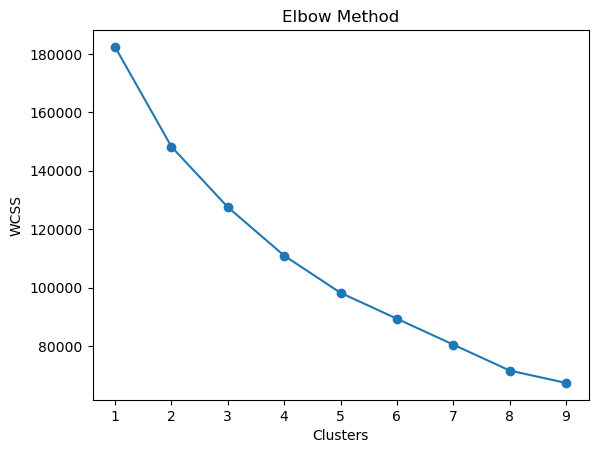

In [11]:
wcss = []

for i in range(1,10):
    km = KMeans(n_clusters=i, random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.plot(range(1,10), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.show()

In [12]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

In [13]:
score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.1717874539952837


In [14]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
df['DBSCAN'] = dbscan.fit_predict(X_scaled)

In [15]:
agg = AgglomerativeClustering(n_clusters=3)
df['Agg_Cluster'] = agg.fit_predict(X_scaled)

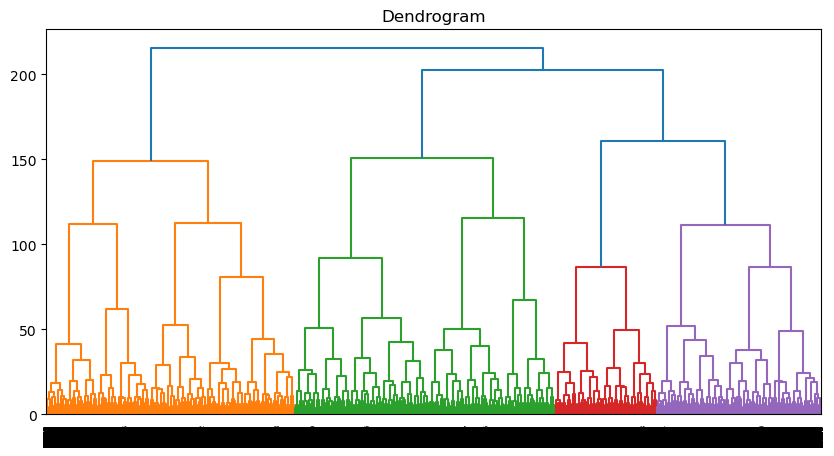

In [16]:
plt.figure(figsize=(10,5))
sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title("Dendrogram")
plt.show()

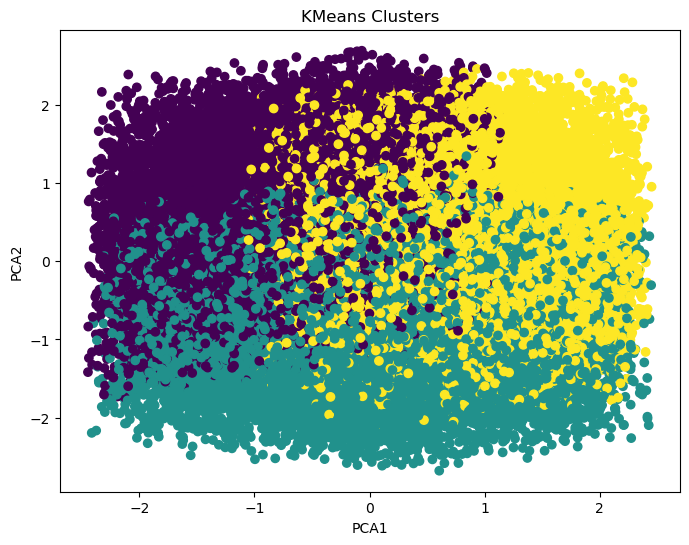

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis')
plt.title("KMeans Clusters")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.show()   

In [18]:
df.groupby('Cluster')[features].mean()

,Age,TotalOrders,AvgSpend,AppUsageTime
Cluster,,,,
0,27.217611,16.194195,541.357684,62.204431
1,38.645425,39.850782,549.009279,61.818861
2,49.672303,16.074614,557.348059,62.080180


## Insights

Cluster 0: Low spenders and low engagement users → Target with discounts  
Cluster 1: High spenders → Provide premium offers and loyalty rewards  
Cluster 2: Frequent users → Personalized recommendations and push notifications  

## Conclusion

Customer segmentation was performed using K-Means clustering. PCA helped visualize data in reduced dimensions. DBSCAN identified noise, while Agglomerative clustering showed hierarchical relationships. Silhouette Score validated the model performance.

Synthetic features were created due to lack of direct behavioral data.

## Limitations

- KMeans assumes spherical clusters  
- Sensitive to scaling  
- Synthetic features used  
- DBSCAN requires parameter tuning  

In [19]:
import pickle

scaler = pickle.load(open("scaler.pkl", "rb"))
pca = pickle.load(open("pca.pkl", "rb"))
kmeans = pickle.load(open("kmeans.pkl", "rb"))